In [2]:
import torch
import math
import einops
import itertools
import matplotlib.pyplot as plt

from omegaconf import OmegaConf

from experiment import Experiment
from utils.config import *
from utils.components import *
from utils.masking import BinaryMasking, ForecastMasking
from utils.einmask import EinMask
from utils.loss_fn import f_kernel_crps

In [33]:
def task_confusion(grads: Dict[str, List[torch.Tensor]]) -> Dict[Tuple[str, str], float]:
    keys = list(grads.keys())
    confusion = {}
    for ki in keys:
        for kj in keys:
            if ki == kj:
                continue
            cos = sum(
                torch.nn.functional.cosine_similarity(gi.flatten(), gj.flatten(), dim=0)
                for gi, gj in zip(grads[ki], grads[kj])
            ) / len(grads[ki])
            confusion[(ki, kj)] = cos.item()
    return confusion

In [34]:
cfg_file = OmegaConf.load('mae.yaml')
config = MTMConfig.from_omegaconf(cfg_file.get("defaults", {}))
experiment = Experiment(config)
experiment.device = 'cuda:0'

In [35]:
experiment.model = experiment.create_model().to(experiment.device)

In [36]:
state_dict = torch.load('runs/2438503/best.pth', map_location=experiment.device)
experiment.model.load_state_dict(state_dict.get('model_state'))

<All keys matched successfully>

In [37]:
val_ds = experiment.godas_data()
val_dl = torch.utils.data.DataLoader(
        val_ds,
        batch_size=8,
        num_workers=0,
        drop_last=True,
        shuffle=False,
        pin_memory=True,
        )
lsm = torch.logical_not(val_ds.land_sea_mask.to(device=experiment.device, dtype=torch.bool))

In [38]:
def node_crps(ens: torch.Tensor, obs: torch.Tensor, mask: torch.BoolTensor):
        score = f_kernel_crps(observation=obs, ensemble=ens, fair = True)
        loss = (score * per_variable_weights)[mask].mean()
        return loss

def spectral_crps( ens: torch.Tensor, obs: torch.Tensor):
    w_v = per_variable_weights.mean(dim = (-1, -2, -3))
    with torch.amp.autocast(enabled = True, device_type = "cuda", dtype = torch.float32):
        e_fft = torch.fft.rfftn(ens.float(), dim = (-2, -3, -4)) #[B, V, ft, fh, fw, E]
        o_fft = torch.fft.rfftn(obs.float(), dim = (-1, -2, -3))
    score = f_kernel_crps(observation=o_fft, ensemble= e_fft, fair = True).mean(dim=(-1, -2, -3)) #[B, V]
    return (score * w_v).mean()

In [39]:
# weights = {
#         'temp_ocn_0a': 1.,
#         'temp_ocn_1a': 0.1,
#         'temp_ocn_3a': 0.1,
#         'temp_ocn_5a': 0.1,
#         'temp_ocn_8a': 0.1,
#         'temp_ocn_11a': 0.1,
#         'temp_ocn_14a': 0.1,
#         'tauxa': 0.01,
#         'tauya': 0.01,
#     }
# w = torch.as_tensor([weights.get(var, 1.) for var in experiment.data_cfg.variables], device = experiment.device)
# per_variable_weights = einops.repeat(w, f"(v vv) -> {experiment.world.field_pattern}", 
#                                                 **experiment.world.token_sizes, **experiment.world.patch_sizes)

per_variable_weights = torch.ones(experiment.world.field_shape, device=experiment.device)

In [62]:
batch = next(iter(val_dl))
batch = batch.to(experiment.device)
B = batch.size(0)
torch._functorch.config.donated_buffer = False

In [41]:
masking = BinaryMasking(experiment.world, event_cfg={}, rate_cfg={"stratify": True}).to(experiment.device)

event_cfgs = {
    'time': {"t": 0.1},
    'space': {"h": 0.1, "w": 0.1},
    'variable': {"v": 0.1},
    'mixed': {"v": 1., "t": 0.1, "h": None, "w": None},
}

rate_cfgs = {
    'src' : {'min': 1/3, 'max': 1/3},
    'tgt' : {'min': 2/3, 'max': 2/3},
}

frcst_rates = {
    'src' : {'min': 1/3, 'max': 1/3},
    'tgt' : {'min': 2/3, 'max': 2/3},
}

In [42]:

alphas = [0.31, 0.62, 3.1, 10]
event_cfgs = {
    f"{alphas[v]}, {alphas[t]},{alphas[hw]}" : {"v": alphas[v], "t": alphas[t], "h": alphas[hw], "w": alphas[hw]}
    for (v, t, hw) in itertools.permutations(range(len(alphas)), len(experiment.world.layout) - 1)
}

In [17]:
vs = [0.31, None]
ts = [0.31, None]
hws = [0.5, 3.1, None]
ps = [0.1, 3.1, None]

event_cfgs = {}
for v, t, hw, p in itertools.product(vs, ts, hws, ps):
    event_cfgs[f'mixed_{v}_{t}_{hw}_{p}'] = {"v": v, "t": t, "h": hw, "w": hw, 'prefix': p}

event_list = [{"v": v, "t": t, "h": hw, "w": hw, 'prefix': p} for v, t, hw, p in itertools.product(vs, ts, hws, ps) ]
#event_cfgs = {f"prior_{i}": {'v':1.,'t': 0.5, 'prefix': 0.5} for i in range(8)}

# alphas = [0.1, 0.31, 1., None]
# event_cfgs = {
#     f"{alphas[v]}, {alphas[t]}, {alphas[hw]}, {alphas[p]}" : {"v": alphas[v], "t": alphas[t], "h": alphas[hw], "w": alphas[hw], 'prefix': alphas[p]}
#     for (v, t, hw, p) in itertools.permutations(range(len(alphas)), len(experiment.world.layout))
# }

# event_cfgs = {
#     f'mixed_{i}': {'t': 0.31, 'prefix': 1.} for i in range(16)
# }

# event_cfgs.update({
#     'time': {"t": 1e-3},
#     'space': {"h": 1e-3, "w": 1e-3},
#     'variable': {"v": 1e-3},
#     'frcst': {'prefix': 1e-3},
# })

In [18]:
print(len(event_list))
print(event_list)
sum([exists(cfg.get('prefix')) for cfg in event_list])

36
[{'v': 0.31, 't': 0.31, 'h': 0.5, 'w': 0.5, 'prefix': 0.1}, {'v': 0.31, 't': 0.31, 'h': 0.5, 'w': 0.5, 'prefix': 3.1}, {'v': 0.31, 't': 0.31, 'h': 0.5, 'w': 0.5, 'prefix': None}, {'v': 0.31, 't': 0.31, 'h': 3.1, 'w': 3.1, 'prefix': 0.1}, {'v': 0.31, 't': 0.31, 'h': 3.1, 'w': 3.1, 'prefix': 3.1}, {'v': 0.31, 't': 0.31, 'h': 3.1, 'w': 3.1, 'prefix': None}, {'v': 0.31, 't': 0.31, 'h': None, 'w': None, 'prefix': 0.1}, {'v': 0.31, 't': 0.31, 'h': None, 'w': None, 'prefix': 3.1}, {'v': 0.31, 't': 0.31, 'h': None, 'w': None, 'prefix': None}, {'v': 0.31, 't': None, 'h': 0.5, 'w': 0.5, 'prefix': 0.1}, {'v': 0.31, 't': None, 'h': 0.5, 'w': 0.5, 'prefix': 3.1}, {'v': 0.31, 't': None, 'h': 0.5, 'w': 0.5, 'prefix': None}, {'v': 0.31, 't': None, 'h': 3.1, 'w': 3.1, 'prefix': 0.1}, {'v': 0.31, 't': None, 'h': 3.1, 'w': 3.1, 'prefix': 3.1}, {'v': 0.31, 't': None, 'h': 3.1, 'w': 3.1, 'prefix': None}, {'v': 0.31, 't': None, 'h': None, 'w': None, 'prefix': 0.1}, {'v': 0.31, 't': None, 'h': None, 'w': 

24

In [112]:
tasks = {}
for key, task in event_cfgs.items():
    masking.event_cfg = task
    P = masking.event_prior(B)
    M = masking.binary_topk_(P, 1200)
    tasks[(key, "src")] = M
    tasks[(key, "tgt")] = M.logical_not()

In [113]:
task_gradients = {}
keys = list(event_cfgs.keys())
        
for key in keys:
    src, tgt = tasks[(key,'src')], tasks[(key,'tgt')]
    mask = torch.logical_and(experiment.mask_to_field(tgt), lsm)
    with torch.amp.autocast(device_type="cuda"):
        #with torch.no_grad(): prediction = experiment.model(batch, src, members = 4)
        prediction = experiment.model(batch, src, members = 4)
        prediction = prediction * lsm[..., None]

    spectral_loss = spectral_crps(prediction, batch) * 0.01
    node_loss = node_crps(prediction, batch, mask)
    mae_loss = (prediction.mean(-1) - batch).abs()[mask].mean()
    
    experiment.model.zero_grad()
    (spectral_loss + node_loss).backward(retain_graph = False)
    task_gradients[key] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]

    # experiment.model.zero_grad()
    # spectral_loss.backward(retain_graph = True)
    # task_gradients[(key,'spectral')] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]

    # experiment.model.zero_grad()
    # node_loss.backward(retain_graph = False)
    # task_gradients[(key, 'node')] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]

    # experiment.model.zero_grad()
    # mae_loss.mean().backward(retain_graph = False)
    # task_gradients[(key,'mae')] = [m.grad.clone() for m in experiment.model.parameters() if m.requires_grad]


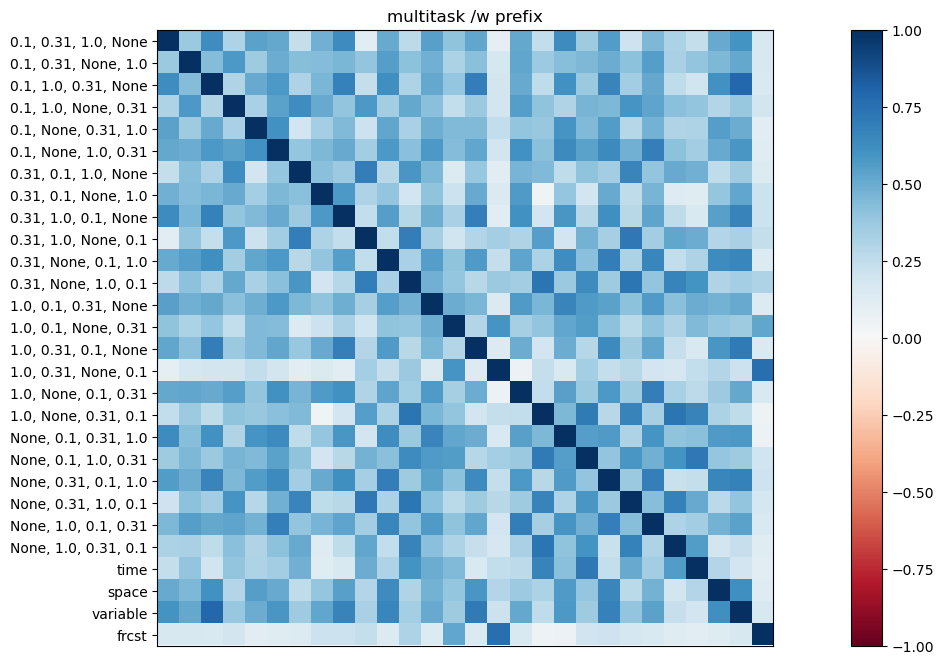

In [114]:

confusion = task_confusion(task_gradients)
keys = list(task_gradients.keys())

matrix = torch.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        matrix[i, j] = confusion.get((ki, kj), 1.0)  # diagonal = 1

fig, ax = plt.subplots(figsize = (20, 8))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap='RdBu')
ax.set_xticks([])
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys)
plt.colorbar(im)
plt.title('multitask /w prefix')
plt.show()

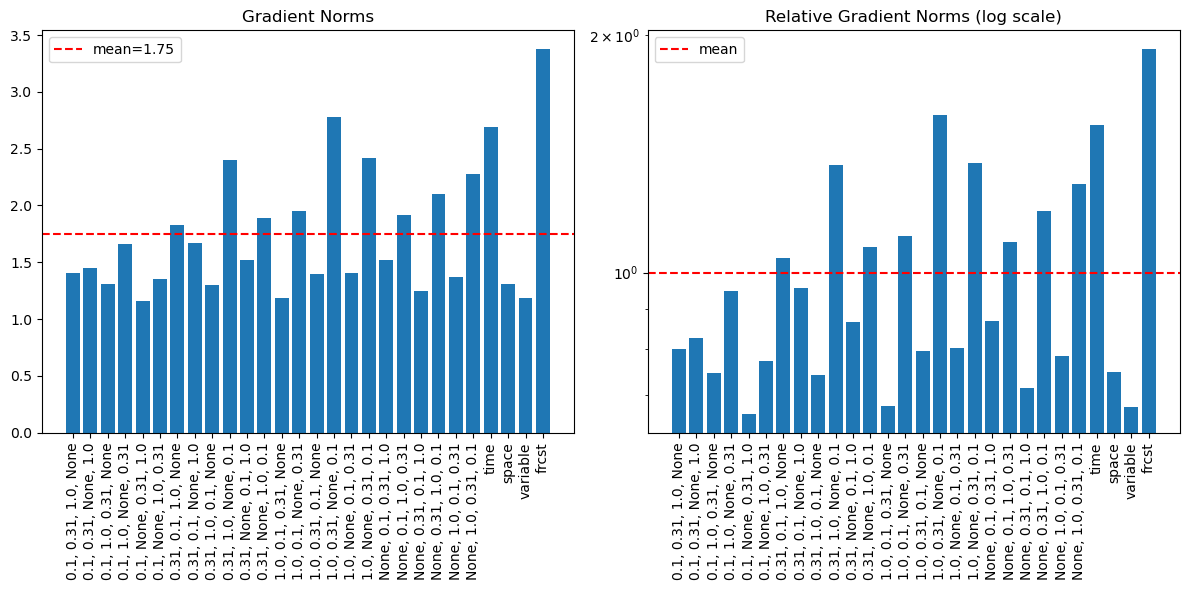

In [115]:
norms = {
    key: sum(g.norm().item() ** 2 for g in grads) ** 0.5
    for key, grads in task_gradients.items()
}

keys = list(norms.keys())
values = list(norms.values())
mean_norm = sum(values) / len(values)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# absolute norms
axes[0].bar(range(len(keys)), values)
axes[0].axhline(mean_norm, color='r', linestyle='--', label=f'mean={mean_norm:.2f}')
axes[0].set_xticks(range(len(keys)))
axes[0].set_xticklabels(keys, rotation=90)
axes[0].set_title('Gradient Norms')
axes[0].legend()

# relative norms (log scale to see variance clearly)
axes[1].bar(range(len(keys)), [v / mean_norm for v in values])
axes[1].axhline(1.0, color='r', linestyle='--', label='mean')
axes[1].set_xticks(range(len(keys)))
axes[1].set_xticklabels(keys, rotation=90)
axes[1].set_yscale('log')
axes[1].set_title('Relative Gradient Norms (log scale)')
axes[1].legend()

plt.tight_layout()
